# 9.5

## a)

In [363]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression

from matplotlib.ticker import MultipleLocator

In [378]:
df = pd.read_csv("../../Datasets_from_the_book/cancersurvival.dat", sep="\s+", dtype=int)
categories = df.columns.tolist()
data = df.to_numpy()

### Data splitting and visualization

In [379]:
data

array([[  25,    1],
       [  42,    1],
       [  45,    1],
       [  46,    1],
       [  51,    1],
       [ 103,    1],
       [ 124,    1],
       [ 146,    1],
       [ 340,    1],
       [ 396,    1],
       [ 412,    1],
       [ 876,    1],
       [1112,    1],
       [  24,    2],
       [  40,    2],
       [ 719,    2],
       [ 727,    2],
       [ 791,    2],
       [1166,    2],
       [1235,    2],
       [1581,    2],
       [1804,    2],
       [3460,    2],
       [3808,    2]])

In [380]:
# Splitting the data into two classes
class1_indices = data[:,1] == 1
class2_indices = data[:,1] == 2

class1_data = data[class1_indices, 0]
class2_data = data[class2_indices, 0]

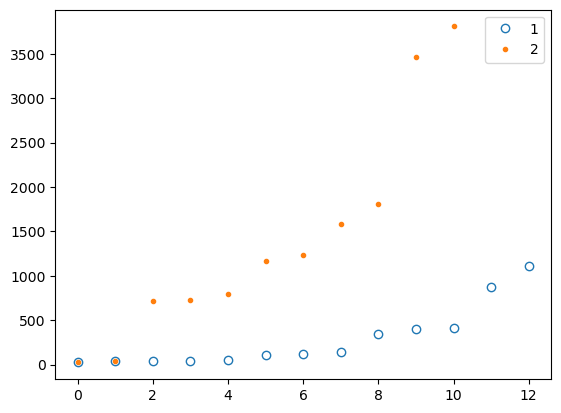

In [381]:
plt.plot(class1_data, "o", markerfacecolor="none", label="1")
plt.plot(class2_data, ".", label="2")
plt.legend()
plt.show()

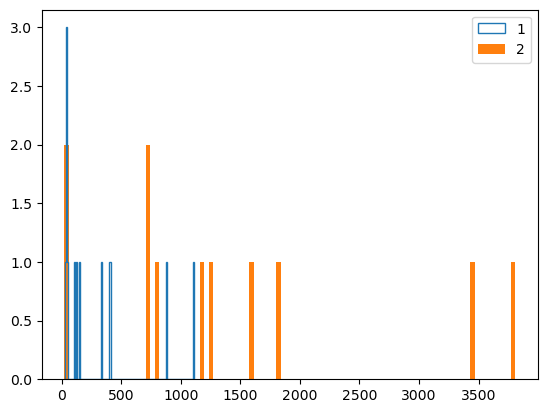

In [382]:
plt.hist(class1_data, histtype="step", label="1", bins=100)
plt.hist(class2_data, label="2", bins=100)
plt.legend()
plt.show()

In [383]:
data[:,1]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

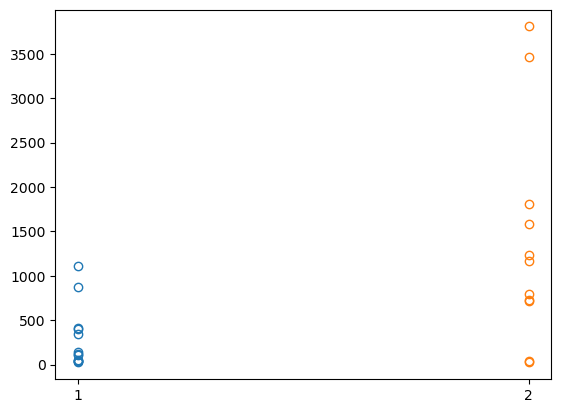

In [384]:
plt.plot(np.ones(len(class1_data)), class1_data, "o", markerfacecolor="none")
plt.plot(np.ones(len(class2_data))*2, class2_data, "o", markerfacecolor="none")

# Integer scale on x-axis
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

plt.show()

### Analysis

In [385]:
class1_data = np.log(class1_data)
class2_data = np.log(class2_data)

In [387]:
mean_estimate_orig_sample_class1 = np.mean(class1_data)
mean_estimate_orig_sample_class2 = np.mean(class2_data)

var_estimate_orig_sample_class1 = np.var(class1_data, ddof=1)
var_estimate_orig_sample_class2 = np.var(class2_data, ddof=1)

print(mean_estimate_orig_sample_class1)
print(mean_estimate_orig_sample_class2)

print(var_estimate_orig_sample_class1)
print(var_estimate_orig_sample_class2)

4.9679197601261125
6.558603409568335
1.5630181987349474
2.715096612410358


In [389]:
def R(mean_estimate_bs_sample, mean_estimate_orig_sample, var_estimate_bs_sample):
    T_F_hat = mean_estimate_bs_sample
    T_F = mean_estimate_orig_sample

    return (T_F_hat - T_F)/np.sqrt(var_estimate_bs_sample)

In [390]:
rng = np.random.default_rng(seed=42)

n_bootstraps = 1000

n_samples_class1 = len(class1_data)
# n_samples_class2 = len(class2_data)

bootstraps_class1 = np.zeros(n_bootstraps)
for i in range(n_bootstraps):
    bs_sample_class1 = rng.choice(class1_data, n_samples_class1, replace=True)
    mean_estimate_bs_sample_class1 = np.mean(bs_sample_class1)
    var_estimate_bs_sample_class1 = np.var(bs_sample_class1)/n_samples_class1
    bootstraps_class1[i] = R(mean_estimate_bs_sample_class1, mean_estimate_orig_sample_class1, var_estimate_bs_sample_class1)

In [392]:
bias_class1 = np.mean(bootstraps_class1) - mean_estimate_orig_sample_class1
corrected_class1 = mean_estimate_orig_sample_class1 - bias_class1
print(corrected_class1)

10.030056068313591


In [393]:
ci95_low_class1 = (mean_estimate_orig_sample_class1 - np.sqrt(var_estimate_orig_sample_class1/n_samples_class1)*np.percentile(bootstraps_class1, [97.5])).item()
ci95_high_class1 = (mean_estimate_orig_sample_class1 - np.sqrt(var_estimate_orig_sample_class1/n_samples_class1)*np.percentile(bootstraps_class1, [2.5])).item()

[ci95_low_class1, ci95_high_class1]

[4.218497657966687, 5.840732756623656]